Importação de bibliotecas

In [2]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Caminho do Dataset Ouro (que criamos no passo anterior)
ARQUIVO_OURO = '../data/gold/dataset_modelagem.parquet'

# Carregar
df = pd.read_parquet(ARQUIVO_OURO)

# Registrar no DuckDB para usar SQL
con = duckdb.connect()
con.register('dados', df)

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dataset carregado: 16783 linhas e 28 colunas.


,ano,nome_origem,populacao,tx_envelhecimento,nome_limpo,codmun,nome_temp,nome_norm,mortes_cardio,leitos_sus,...,pib_total,taxa_mortalidade,leitos_por_mil,medicos_por_100k,estab_por_100k,pib_per_capita_calc,tem_hospital,cod_uf,cod_regiao,regiao
0,2007,Alta Floresta D'Oeste (RO),26533.0,4.595,None,110001,None,None,21.0,45.0,...,191364.0,79.146723,1.696001,678.400482,45.226699,7212.301662,1,11,1,Norte
1,2010,Alta Floresta D'Oeste (RO),24392.0,5.840,ALTA FLORESTA D'OESTE,110001,Alta Floresta D'Oeste,ALTA FLORESTA D'OESTE,16.0,45.0,...,262077.0,65.595277,1.844867,828.140374,61.495572,10744.383404,1,11,1,Norte
2,2015,Alta Floresta D'Oeste (RO),24392.0,5.840,None,110001,None,None,32.0,45.0,...,421300.0,131.190554,1.844867,1078.222368,98.392916,17272.056412,1,11,1,Norte
3,2007,Ariquemes (RO),74503.0,3.640,None,110002,None,None,69.0,66.0,...,905203.0,92.613720,0.885870,744.936446,59.058025,12149.886582,1,11,1,Norte
4,2010,Ariquemes (RO),90353.0,4.360,ARIQUEMES,110002,Ariquemes,ARIQUEMES,98.0,66.0,...,1364694.0,108.463471,0.730468,913.085343,92.968689,15104.025323,1,11,1,Norte


Consultas SQL Analíticas

In [6]:
print("=== 1. Análise Temporal: A mortalidade está crescendo ou caindo? ===")
q1 = """
SELECT 
    ano, 
    COUNT(*) as qtd_cidades,
    AVG(taxa_mortalidade)::INT as media_mortalidade_br,
    SUM(mortes_cardio) as total_obitos_ano
FROM dados 
GROUP BY ano 
ORDER BY ano
"""
print(con.execute(q1).df())

print("\n=== 2. Ranking Regional: Qual região é a mais crítica (2015)? ===")
q2 = """
SELECT 
    regiao,
    AVG(taxa_mortalidade)::INT as taxa_media,
    AVG(idhm)::DECIMAL(4,3) as idhm_medio,
    AVG(medicos_por_100k)::INT as medicos_media
FROM dados 
WHERE ano = 2015 
GROUP BY regiao 
ORDER BY taxa_media DESC
"""
print(con.execute(q2).df())

print("\n=== 3. Desigualdade: Ricos morrem menos? (Agrupamento por Quartil de Renda) ===")
# CORREÇÃO AQUI: Usamos WITH (CTE) para calcular o quartil ANTES de agrupar
q3 = """
WITH base_quartil AS (
    SELECT 
        renda_pc,
        taxa_mortalidade,
        ntile(4) OVER (ORDER BY renda_pc) as quartil_renda
    FROM dados 
    WHERE ano = 2015 AND renda_pc IS NOT NULL
)
SELECT 
    quartil_renda,
    MIN(renda_pc)::INT as renda_minima,
    MAX(renda_pc)::INT as renda_maxima,
    AVG(taxa_mortalidade)::INT as media_mortalidade
FROM base_quartil
GROUP BY quartil_renda 
ORDER BY quartil_renda
"""
print(con.execute(q3).df())

print("\n=== 4. Impacto do Porte: Cidades Pequenas vs Grandes ===")
q4 = """
SELECT 
    CASE 
        WHEN populacao < 20000 THEN '1. Pequena (<20k)'
        WHEN populacao < 100000 THEN '2. Média (20k-100k)'
        ELSE '3. Grande (>100k)' 
    END as porte,
    COUNT(*) as qtd,
    AVG(taxa_mortalidade)::INT as taxa_mortalidade_media,
    AVG(leitos_por_mil)::DECIMAL(4,2) as leitos_mil_media
FROM dados 
WHERE ano = 2015
GROUP BY 1 
ORDER BY 1
"""
print(con.execute(q4).df())

print("\n=== 5. Detectando Anomalias: Cidades com mortalidade explosiva (Top 5) ===")
q5 = """
SELECT nome_origem, ano, populacao, taxa_mortalidade, idhm -- CORREÇÃO AQUI
FROM dados 
WHERE populacao > 10000 -- Filtrar cidades minusculas que distorcem a taxa
ORDER BY taxa_mortalidade DESC 
LIMIT 5
"""
print(con.execute(q5).df())

=== 1. Análise Temporal: A mortalidade está crescendo ou caindo? ===
    ano  qtd_cidades  media_mortalidade_br  total_obitos_ano
0  2007         5277                   189          296602.0
1  2010         6229                   246          365882.0
2  2015         5277                   202          334843.0

=== 2. Ranking Regional: Qual região é a mais crítica (2015)? ===
         regiao  taxa_media  idhm_medio  medicos_media
0           Sul         228       0.714           1185
1       Sudeste         206       0.698           1212
2      Nordeste         197       0.591            972
3  Centro-Oeste         185       0.688           1322
4         Norte         150       0.605           1358

=== 3. Desigualdade: Ricos morrem menos? (Agrupamento por Quartil de Renda) ===
   quartil_renda  renda_minima  renda_maxima  media_mortalidade
0              1            96           284                204
1              2           284           476                192
2              3 

## Análise Univariada 
Mostra como a mortalidade se comporta

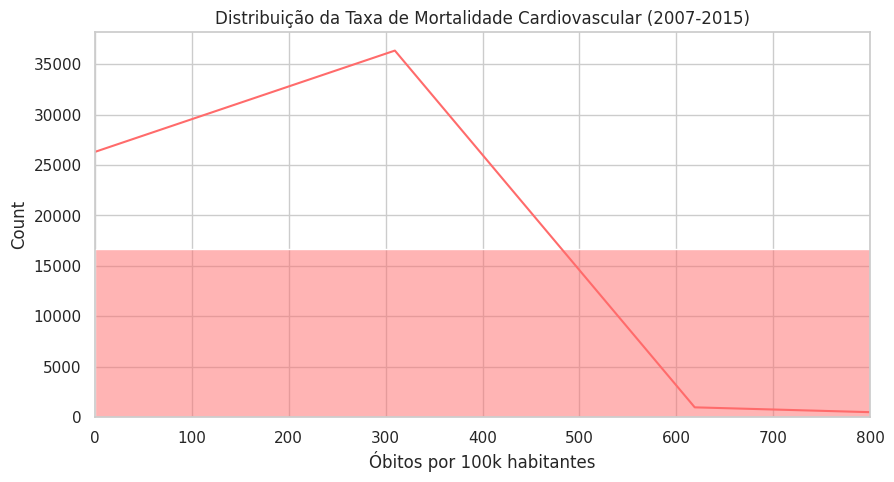

Média: 214.21
Mediana: 175.45


In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['taxa_mortalidade'], kde=True, bins=50, color='#ff6b6b')
plt.title('Distribuição da Taxa de Mortalidade Cardiovascular (2007-2015)')
plt.xlabel('Óbitos por 100k habitantes')
plt.xlim(0, 800) # Limitando visualmente para focar na maioria
plt.show()

print(f"Média: {df['taxa_mortalidade'].mean():.2f}")
print(f"Mediana: {df['taxa_mortalidade'].median():.2f}")
# Se a Média > Mediana, a curva tem cauda para a direita (cidades com mortalidade extrema)

## Análise Bivariada
Mapa de calor que mostra o que influencia o quê.

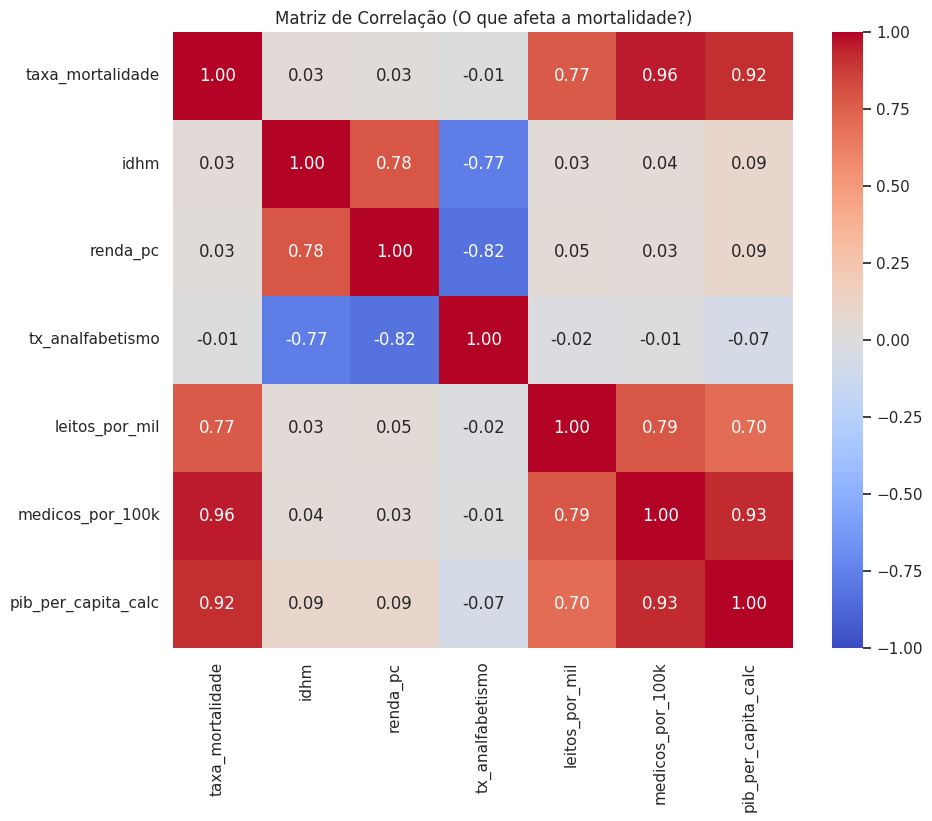

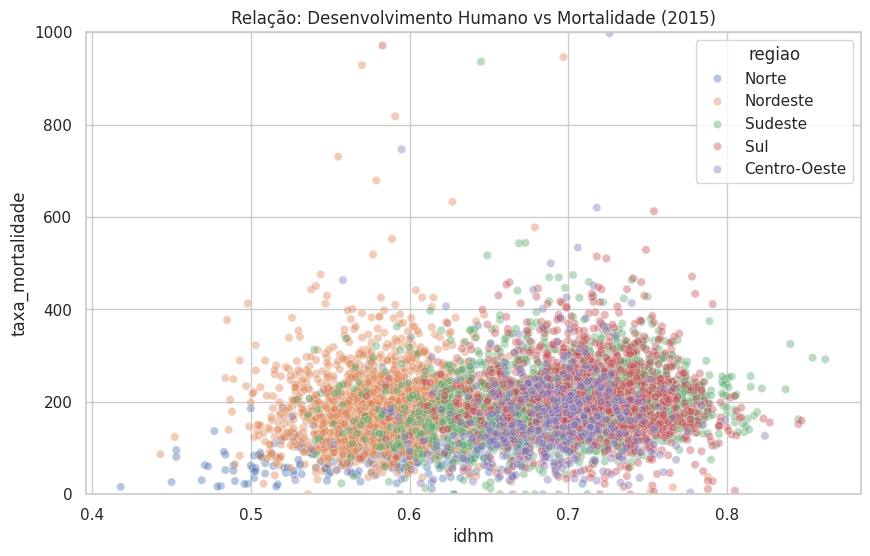

In [8]:
# Selecionar variáveis numéricas relevantes
cols_corr = [
    'taxa_mortalidade', 'idhm', 'renda_pc', 'tx_analfabetismo',
    'leitos_por_mil', 'medicos_por_100k', 'pib_per_capita_calc'
]

# Calcular matriz
corr = df[cols_corr].corr()

# Plotar Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação (O que afeta a mortalidade?)')
plt.show()

# Scatterplot Focado: IDHM vs Mortalidade
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['ano']==2015], x='idhm', y='taxa_mortalidade', alpha=0.4, hue='regiao')
plt.title('Relação: Desenvolvimento Humano vs Mortalidade (2015)')
plt.ylim(0, 1000)
plt.show()

## Teste de Hipóteses
### Hipótese H1: Cidades com IDHM baixo (< 0.70) têm média de mortalidade maior que cidades com IDHM alto (>= 0.70)

In [9]:
print("=== Teste de Hipóteses H1 (Do Projeto) ===")

# 1. Criar os grupos baseados no seu corte de 0.70
# Vamos remover nulos de IDHM para não dar erro
df_valid = df.dropna(subset=['idhm', 'taxa_mortalidade'])

grupo_idhm_baixo = df_valid[df_valid['idhm'] < 0.70]['taxa_mortalidade']
grupo_idhm_alto = df_valid[df_valid['idhm'] >= 0.70]['taxa_mortalidade']

# 2. Estatísticas Descritivas
media_baixo = grupo_idhm_baixo.mean()
media_alto = grupo_idhm_alto.mean()

print(f"\nNº Cidades IDHM Baixo (<0.70): {len(grupo_idhm_baixo)}")
print(f"Média Mortalidade (Baixo IDHM): {media_baixo:.2f}")
print("-" * 30)
print(f"Nº Cidades IDHM Alto (>=0.70): {len(grupo_idhm_alto)}")
print(f"Média Mortalidade (Alto IDHM):  {media_alto:.2f}")

# 3. Rodar o Teste T de Student (Comparação de Médias)
# Alternative='greater' testa se a média do primeiro grupo é MAIOR que a do segundo
t_stat, p_val = stats.ttest_ind(grupo_idhm_baixo, grupo_idhm_alto, equal_var=False, alternative='greater')

print(f"\nEstatística T: {t_stat:.4f}")
print(f"Valor P: {p_val:.10f}")

# 4. Conclusão Automática
alpha = 0.05
if p_val < alpha:
    print("\n✅ H1 CONFIRMADA (Estatísticamente Significativa)")
    print("Há evidências de que cidades com baixo desenvolvimento humano têm maior taxa de mortalidade cardiovascular.")
    print(f"Diferença média de: {media_baixo - media_alto:.2f} mortes por 100k hab.")
else:
    print("\n❌ H1 REFUTADA")
    print("Não há diferença estatística significativa entre os grupos de IDHM.")

=== Teste de Hipóteses H1 (Do Projeto) ===

Nº Cidades IDHM Baixo (<0.70): 12628
Média Mortalidade (Baixo IDHM): 204.91
------------------------------
Nº Cidades IDHM Alto (>=0.70): 4155
Média Mortalidade (Alto IDHM):  242.49

Estatística T: -2.1203
Valor P: 0.9829862400

❌ H1 REFUTADA
Não há diferença estatística significativa entre os grupos de IDHM.
